# Analiza trendów podatności CVE z wykorzystaniem NVD API
**Autor:** Filip Wójcik  
**Źródło danych:** National Vulnerability Database (NVD) – https://nvd.nist.gov  
**API:** https://services.nvd.nist.gov/rest/json/cves/2.0  

---

## Spis treści
1. [Konfiguracja i importy](#1)
2. [Pobieranie danych z NVD API](#2)
3. [Czyszczenie i przygotowanie danych](#3)
4. [Analiza 1 – Trendy czasowe](#4)
5. [Analiza 2 – Rozkład CVSS Severity](#5)
6. [Analiza 3 – Top CWE (typy podatności)](#6)
7. [Analiza 4 – Top vendorzy i produkty](#7)
8. [Wnioski końcowe](#8)

---
## 1. Konfiguracja i importy <a id='1'></a>

In [41]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import time
import os
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm
from datetime import datetime

# --- Konfiguracja ---
API_BASE_URL = "https://services.nvd.nist.gov/rest/json/cves/2.0"
API_KEY = "648fdcc3-1f57-4282-8393-b39a47ee939e"
DATA_DIR = "../data"
DATA_FILE = os.path.join(DATA_DIR, "cve_data.csv")

# Lata do analizy
START_YEAR = 2015
END_YEAR   = 2024

# Styl wykresów
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "DejaVu Sans"

COLORS = {
    "CRITICAL": "#d62728",
    "HIGH":     "#ff7f0e",
    "MEDIUM":   "#f0b429",
    "LOW":      "#2ca02c",
    "NONE":     "#aec7e8",
    "N/A":      "#c7c7c7",
}

print("✅ Konfiguracja załadowana.")
print(f"   Zakres lat: {START_YEAR}–{END_YEAR}")
print(f"   Klucz API: {'ustawiony' if API_KEY else 'brak (limit 5 req/30s)'}")

✅ Konfiguracja załadowana.
   Zakres lat: 2015–2024
   Klucz API: ustawiony


---
## 2. Pobieranie danych z NVD API <a id='2'></a>

Dane pobierane są rok po roku (2015–2024) z uwzględnieniem paginacji API (max 2000 wyników na stronę).  
Wyniki zapisywane są do pliku CSV, aby uniknąć wielokrotnego pobierania.

In [ ]:
def build_headers():
    """Buduje nagłówki HTTP - dodaje klucz API jeśli dostępny."""
    headers = {"Accept": "application/json"}
    if API_KEY:
        headers["apiKey"] = API_KEY
    return headers


def fetch_cves_for_year(year: int) -> list[dict]:
    """
    Pobiera wszystkie CVE dla podanego roku z NVD API.
    Rok dzielony na kwartały (max 120 dni na zapytanie).
    """
    quarters = [
        (f"{year}-01-01T00:00:00.000", f"{year}-03-31T23:59:59.000"),
        (f"{year}-04-01T00:00:00.000", f"{year}-06-30T23:59:59.000"),
        (f"{year}-07-01T00:00:00.000", f"{year}-09-30T23:59:59.000"),
        (f"{year}-10-01T00:00:00.000", f"{year}-12-31T23:59:59.000"),
    ]
    headers     = build_headers()
    all_results = []

    for start, end in quarters:
        start_index      = 0
        results_per_page = 2000
        total            = None

        while True:
            url = (
                f"{API_BASE_URL}"
                f"?pubStartDate={start}&pubEndDate={end}"
                f"&resultsPerPage={results_per_page}&startIndex={start_index}"
            )
            resp = None
            try:
                resp = requests.get(url, headers=headers, timeout=30)
                resp.raise_for_status()
            except requests.exceptions.RequestException as e:
                print(f"  ⚠️  Błąd ({start[:7]}): {e}")
                if resp is not None and resp.status_code == 404:
                    print(f"  ❌ 404 - kwartał pominięty {start[:7]}")
                    break
                time.sleep(10)
                continue

            data  = resp.json()
            if total is None:
                total = data.get("totalResults", 0)

            vulns = data.get("vulnerabilities", [])
            all_results.extend(vulns)

            fetched_so_far = start_index + len(vulns)
            if fetched_so_far >= total:
                break

            start_index = fetched_so_far
            time.sleep(7 if not API_KEY else 1)

    return all_results

def parse_cve(entry: dict) -> dict:
    """
    Wyciąga z surowego JSON-a pola potrzebne do analizy:
    - cve_id, published, last_modified
    - cvss_v3_score, cvss_v3_severity
    - cvss_v2_score, cvss_v2_severity
    - cwe_ids (pipe-separated)
    - vendors (pipe-separated, z CPE)
    """
    cve   = entry.get("cve", {})
    cve_id       = cve.get("id", "")
    published    = cve.get("published", "")[:10]
    last_modified = cve.get("lastModified", "")[:10]

    # --- CVSS v3 ---
    cvss_v3_score    = None
    cvss_v3_severity = "N/A"
    metrics = cve.get("metrics", {})
    for key in ("cvssMetricV31", "cvssMetricV30"):
        if key in metrics and metrics[key]:
            m = metrics[key][0].get("cvssData", {})
            cvss_v3_score    = m.get("baseScore")
            cvss_v3_severity = m.get("baseSeverity", "N/A").upper()
            break

    # --- CVSS v2 ---
    cvss_v2_score    = None
    cvss_v2_severity = "N/A"
    if "cvssMetricV2" in metrics and metrics["cvssMetricV2"]:
        m = metrics["cvssMetricV2"][0].get("cvssData", {})
        cvss_v2_score    = m.get("baseScore")
        cvss_v2_severity = metrics["cvssMetricV2"][0].get("baseSeverity", "N/A").upper()

    # --- CWE ---
    cwe_ids = []
    for weakness in cve.get("weaknesses", []):
        for desc in weakness.get("description", []):
            val = desc.get("value", "")
            if val.startswith("CWE-"):
                cwe_ids.append(val)
    cwe_str = "|".join(set(cwe_ids)) if cwe_ids else "N/A"

    # --- Vendorzy z CPE ---
    vendors = set()
    for config in cve.get("configurations", []):
        for node in config.get("nodes", []):
            for match in node.get("cpeMatch", []):
                cpe = match.get("criteria", "")
                parts = cpe.split(":")
                if len(parts) > 3:
                    vendors.add(parts[3])   # vendor jest na pozycji 3 w CPE 2.3
    vendor_str = "|".join(vendors) if vendors else "N/A"

    return {
        "cve_id":           cve_id,
        "published":        published,
        "last_modified":    last_modified,
        "cvss_v3_score":    cvss_v3_score,
        "cvss_v3_severity": cvss_v3_severity,
        "cvss_v2_score":    cvss_v2_score,
        "cvss_v2_severity": cvss_v2_severity,
        "cwe":              cwe_str,
        "vendors":          vendor_str,
    }


print("✅ Funkcje pobierające zdefiniowane.")

✅ Funkcje pobierające zdefiniowane.


In [44]:
# ---------------------------------------------------------------
# POBIERANIE DANYCH
# Jeśli plik CSV już istnieje – wczytujemy go (pomijamy pobieranie).
# Żeby pobrać świeże dane, usuń plik ../data/cve_data.csv
# ---------------------------------------------------------------

if os.path.exists(DATA_FILE):
    print(f"📂 Znaleziono plik cache: {DATA_FILE}")
    print("   Wczytuję dane z pliku (usuń plik aby pobrać świeże dane)...")
    df_raw = pd.read_csv(DATA_FILE, sep=";")
    print(f"✅ Wczytano {len(df_raw):,} rekordów.")
else:
    print(f"🌐 Brak cache – pobieram dane z NVD API ({START_YEAR}–{END_YEAR})...")
    print("   ⏳ Bez klucza API może to potrwać kilkanaście minut (rate limiting).\n")

    all_parsed = []
    years = list(range(START_YEAR, END_YEAR + 1))

    for year in tqdm(years, desc="Pobieranie lat"):
        raw = fetch_cves_for_year(year)
        parsed = [parse_cve(e) for e in raw]
        all_parsed.extend(parsed)
        print(f"  {year}: {len(parsed):,} CVE")
        time.sleep(7 if not API_KEY else 1)

    df_raw = pd.DataFrame(all_parsed)
    os.makedirs(DATA_DIR, exist_ok=True)
    df_raw.to_csv(DATA_FILE, index=False, sep=";")
    print(f"\n✅ Pobrano łącznie {len(df_raw):,} rekordów → zapisano do {DATA_FILE}")

🌐 Brak cache – pobieram dane z NVD API (2015–2024)...
   ⏳ Bez klucza API może to potrwać kilkanaście minut (rate limiting).



Pobieranie lat:   0%|          | 0/10 [00:00<?, ?it/s]

  2015: 6,595 CVE
  ⚠️  Błąd (2016-07): HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out.
  ⚠️  Błąd (2016-07): HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out.
  2016: 6,517 CVE
  2017: 18,113 CVE
  2018: 18,154 CVE
  ⚠️  Błąd (2019-10): HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out.
  2019: 18,938 CVE
  2020: 19,222 CVE
  2021: 21,950 CVE
  ⚠️  Błąd (2022-07): HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out.
  2022: 26,431 CVE
  ⚠️  Błąd (2023-04): HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out.
  ⚠️  Błąd (2023-07): HTTPSConnectionPool(host='services.nvd.nist.gov', port=443): Read timed out.
  2023: 30,949 CVE
  2024: 40,704 CVE

✅ Pobrano łącznie 207,573 rekordów → zapisano do ../data\cve_data.csv


---
## 3. Czyszczenie i przygotowanie danych <a id='3'></a>

In [49]:
df = df_raw.copy()

# Konwersja dat
df["published"]     = pd.to_datetime(df["published"],     errors="coerce")
df["last_modified"] = pd.to_datetime(df["last_modified"], errors="coerce")

# Kolumny pomocnicze
df["year"]  = df["published"].dt.year
df["month"] = df["published"].dt.to_period("M")

# Normalizacja severity
VALID_SEV = {"CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE"}
df["cvss_v3_severity"] = df["cvss_v3_severity"].where(
    df["cvss_v3_severity"].isin(VALID_SEV), other="N/A"
)
df["cvss_v2_severity"] = df["cvss_v2_severity"].where(
    df["cvss_v2_severity"].isin({"HIGH", "MEDIUM", "LOW"}), other="N/A"
)

# Raport jakości danych
print("\n📊 Podstawowe statystyki zbioru:")
print(f"  Łączna liczba CVE:          {len(df):,}")
print(f"  Zakres dat:                 {df['published'].min().date()} → {df['published'].max().date()}")
print(f"  CVE z oceną CVSS v3:        {df['cvss_v3_score'].notna().sum():,} ({df['cvss_v3_score'].notna().mean():.1%})")
print(f"  CVE z oceną CVSS v2:        {df['cvss_v2_score'].notna().sum():,} ({df['cvss_v2_score'].notna().mean():.1%})")
print(f"  CVE z przypisanym CWE:      {(df['cwe'] != 'N/A').sum():,} ({(df['cwe'] != 'N/A').mean():.1%})")
print(f"  CVE z danymi o vendorze:    {(df['vendors'] != 'N/A').sum():,} ({(df['vendors'] != 'N/A').mean():.1%})")

df.head(3)


📊 Podstawowe statystyki zbioru:
  Łączna liczba CVE:          207,573
  Zakres dat:                 2015-01-01 → 2024-12-31
  CVE z oceną CVSS v3:        186,898 (90.0%)
  CVE z oceną CVSS v2:        117,991 (56.8%)
  CVE z przypisanym CWE:      170,475 (82.1%)
  CVE z danymi o vendorze:    185,946 (89.6%)


,cve_id,published,last_modified,cvss_v3_score,cvss_v3_severity,cvss_v2_score,cvss_v2_severity,cwe,vendors,year,month
0,CVE-2011-5285,2015-01-01,2025-04-12,NaN,N/A,4.3,MEDIUM,CWE-79,bugfree,2015,2015-01
1,CVE-2011-5286,2015-01-01,2025-04-12,NaN,N/A,7.5,HIGH,CWE-89,social_slider_project,2015,2015-01
2,CVE-2011-5287,2015-01-01,2025-04-12,NaN,N/A,4.3,MEDIUM,CWE-79,hesk,2015,2015-01


---
## 4. Analiza 1 – Trendy czasowe <a id='4'></a>

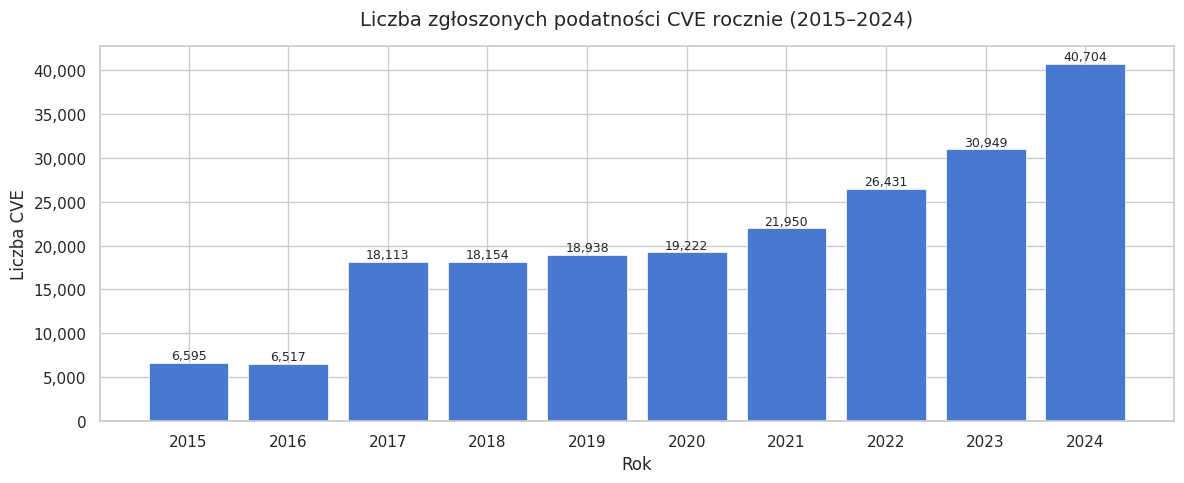

 year  count
 2015   6595
 2016   6517
 2017  18113
 2018  18154
 2019  18938
 2020  19222
 2021  21950
 2022  26431
 2023  30949
 2024  40704


In [47]:
# --- 4a. Liczba CVE rocznie ---
cve_per_year = df.groupby("year").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cve_per_year["year"], cve_per_year["count"], color="#4878cf", edgecolor="white", linewidth=0.5)

# Etykiety na słupkach
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Liczba zgłoszonych podatności CVE rocznie (2015–2024)", fontsize=14, pad=15)
ax.set_xlabel("Rok")
ax.set_ylabel("Liczba CVE")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(cve_per_year["year"])
plt.tight_layout()
plt.savefig("../data/wykres_cve_rocznie.png", dpi=150)
plt.show()
print(cve_per_year.to_string(index=False))

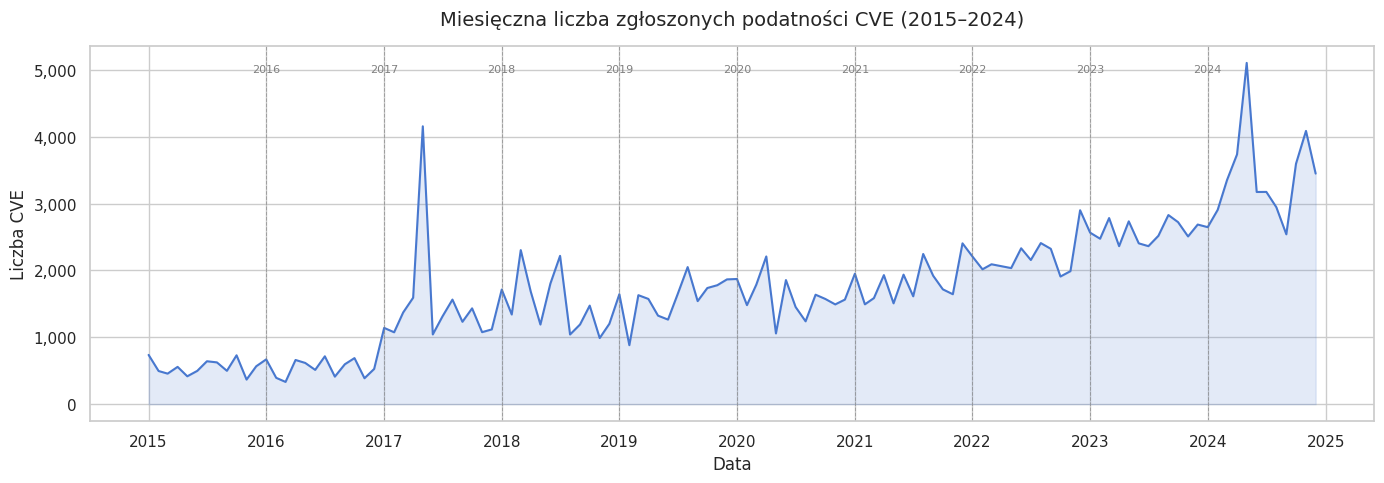

In [48]:
# --- 4b. Trend miesięczny (linia) ---
cve_per_month = df.groupby("month").size().reset_index(name="count")
cve_per_month["month_dt"] = cve_per_month["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cve_per_month["month_dt"], cve_per_month["count"], color="#4878cf", linewidth=1.5)
ax.fill_between(cve_per_month["month_dt"], cve_per_month["count"], alpha=0.15, color="#4878cf")

# Pionowe linie na przełomie lat
for year in range(START_YEAR + 1, END_YEAR + 1):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
    ax.text(pd.Timestamp(f"{year}-01-01"), ax.get_ylim()[1] * 0.95, str(year),
            ha="center", va="top", fontsize=8, color="gray")

ax.set_title("Miesięczna liczba zgłoszonych podatności CVE (2015–2024)", fontsize=14, pad=15)
ax.set_xlabel("Data")
ax.set_ylabel("Liczba CVE")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/wykres_cve_miesieczny.png", dpi=150)
plt.show()

---
## 5. Analiza 2 – Rozkład CVSS Severity <a id='5'></a>

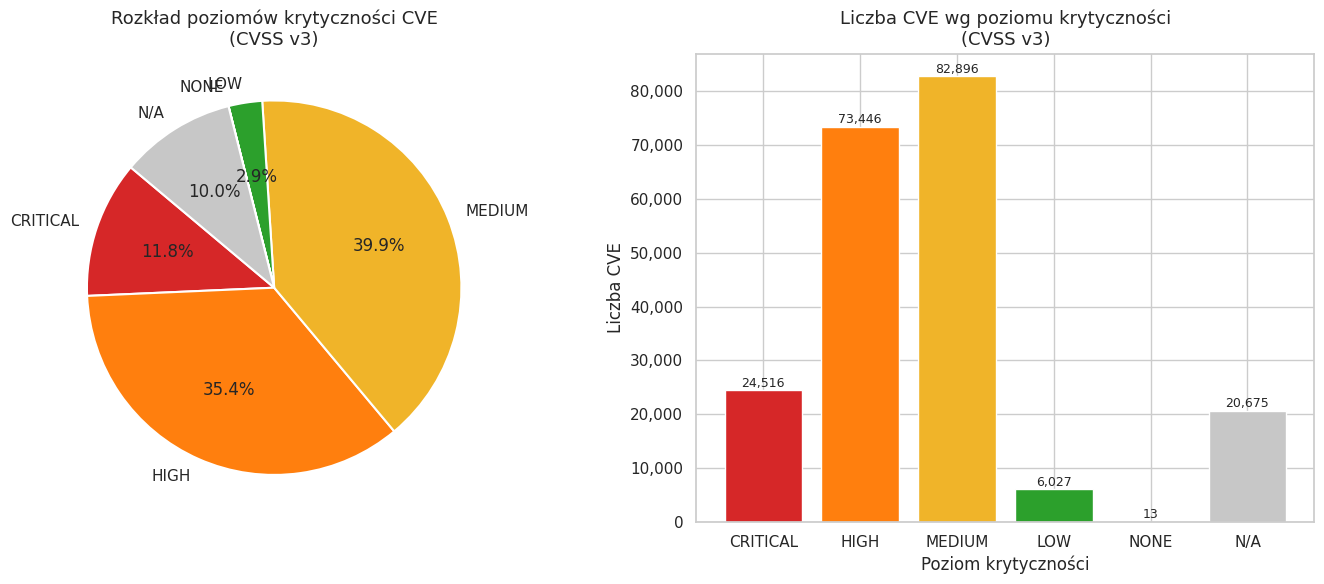

cvss_v3_severity
CRITICAL    24516
HIGH        73446
MEDIUM      82896
LOW          6027
NONE           13
N/A         20675


In [50]:
# --- 5a. Ogólny rozkład CVSS v3 severity (pie + bar) ---
sev_order = ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE", "N/A"]
sev_counts = df["cvss_v3_severity"].value_counts().reindex(sev_order, fill_value=0)
sev_colors = [COLORS[s] for s in sev_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
wedges, texts, autotexts = ax1.pie(
    sev_counts,
    labels=sev_counts.index,
    colors=sev_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax1.set_title("Rozkład poziomów krytyczności CVE\n(CVSS v3)", fontsize=13)

# Bar chart
bars = ax2.bar(sev_counts.index, sev_counts.values, color=sev_colors, edgecolor="white")
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
ax2.set_title("Liczba CVE wg poziomu krytyczności\n(CVSS v3)", fontsize=13)
ax2.set_xlabel("Poziom krytyczności")
ax2.set_ylabel("Liczba CVE")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("../data/wykres_severity.png", dpi=150)
plt.show()
print(sev_counts.to_string())

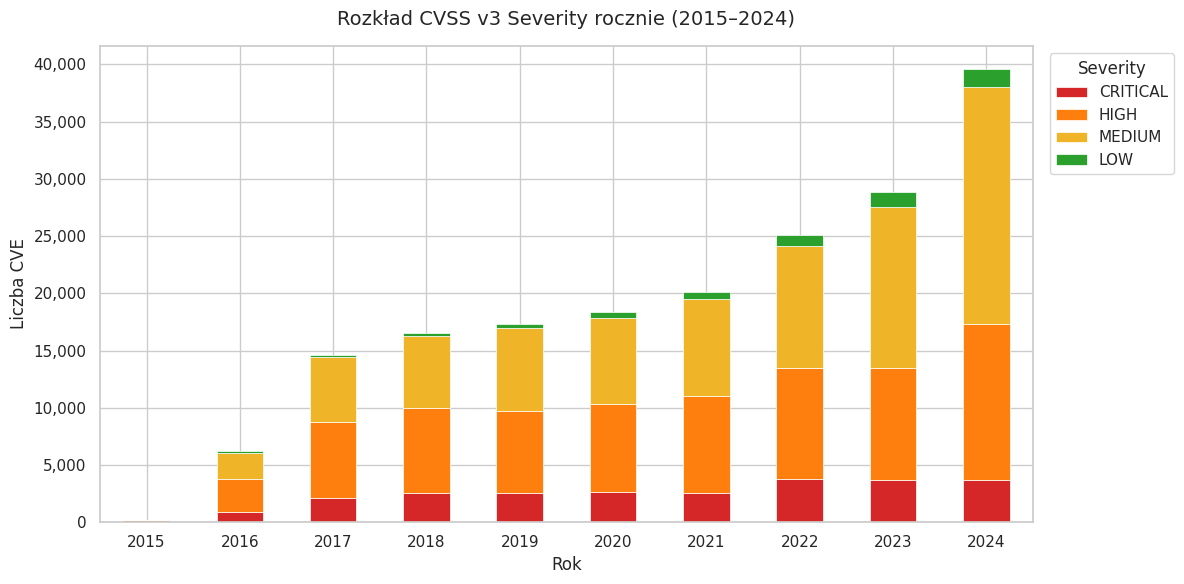

In [51]:
# --- 5b. Severity rocznie – stacked bar ---
sev_year = (
    df[df["cvss_v3_severity"].isin(["CRITICAL", "HIGH", "MEDIUM", "LOW"])]
    .groupby(["year", "cvss_v3_severity"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["CRITICAL", "HIGH", "MEDIUM", "LOW"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
sev_year.plot(
    kind="bar", stacked=True, ax=ax,
    color=[COLORS[s] for s in sev_year.columns],
    edgecolor="white", linewidth=0.5
)
ax.set_title("Rozkład CVSS v3 Severity rocznie (2015–2024)", fontsize=14, pad=15)
ax.set_xlabel("Rok")
ax.set_ylabel("Liczba CVE")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Severity", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/wykres_severity_rocznie.png", dpi=150)
plt.show()

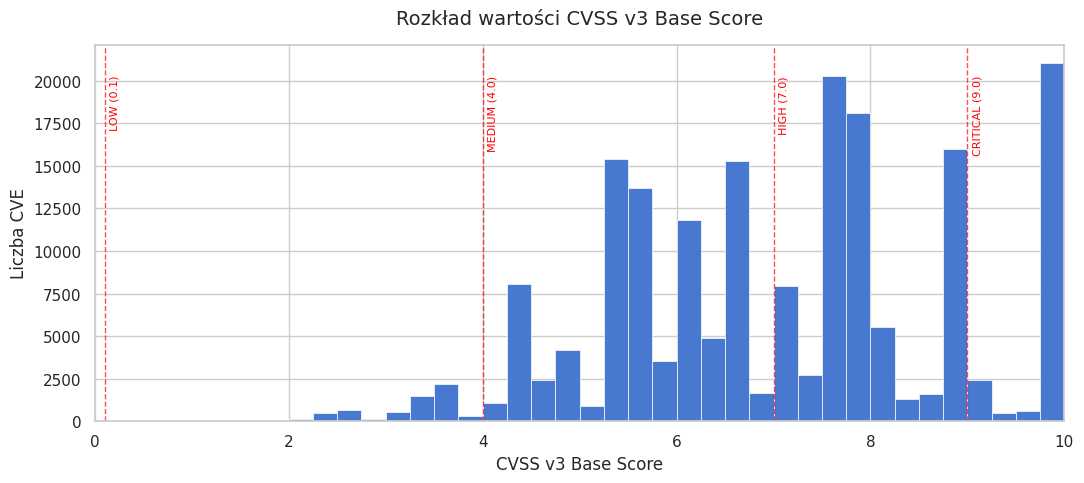

Średni CVSS v3: 6.99
Mediana CVSS v3: 7.20
Odch. stand.: 1.71


In [52]:
# --- 5c. Rozkład score'ów CVSS v3 (histogram) ---
scores = df["cvss_v3_score"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(scores, bins=40, color="#4878cf", edgecolor="white", linewidth=0.5)

# Linie progów severity
thresholds = {"LOW (0.1)": 0.1, "MEDIUM (4.0)": 4.0, "HIGH (7.0)": 7.0, "CRITICAL (9.0)": 9.0}
for label, val in thresholds.items():
    ax.axvline(val, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(val + 0.05, ax.get_ylim()[1] * 0.92, label, fontsize=8, color="red", rotation=90, va="top")

ax.set_title("Rozkład wartości CVSS v3 Base Score", fontsize=14, pad=15)
ax.set_xlabel("CVSS v3 Base Score")
ax.set_ylabel("Liczba CVE")
ax.set_xlim(0, 10)
plt.tight_layout()
plt.savefig("../data/wykres_cvss_histogram.png", dpi=150)
plt.show()

print(f"Średni CVSS v3: {scores.mean():.2f}")
print(f"Mediana CVSS v3: {scores.median():.2f}")
print(f"Odch. stand.: {scores.std():.2f}")

---
## 6. Analiza 3 – Top CWE (typy podatności) <a id='6'></a>

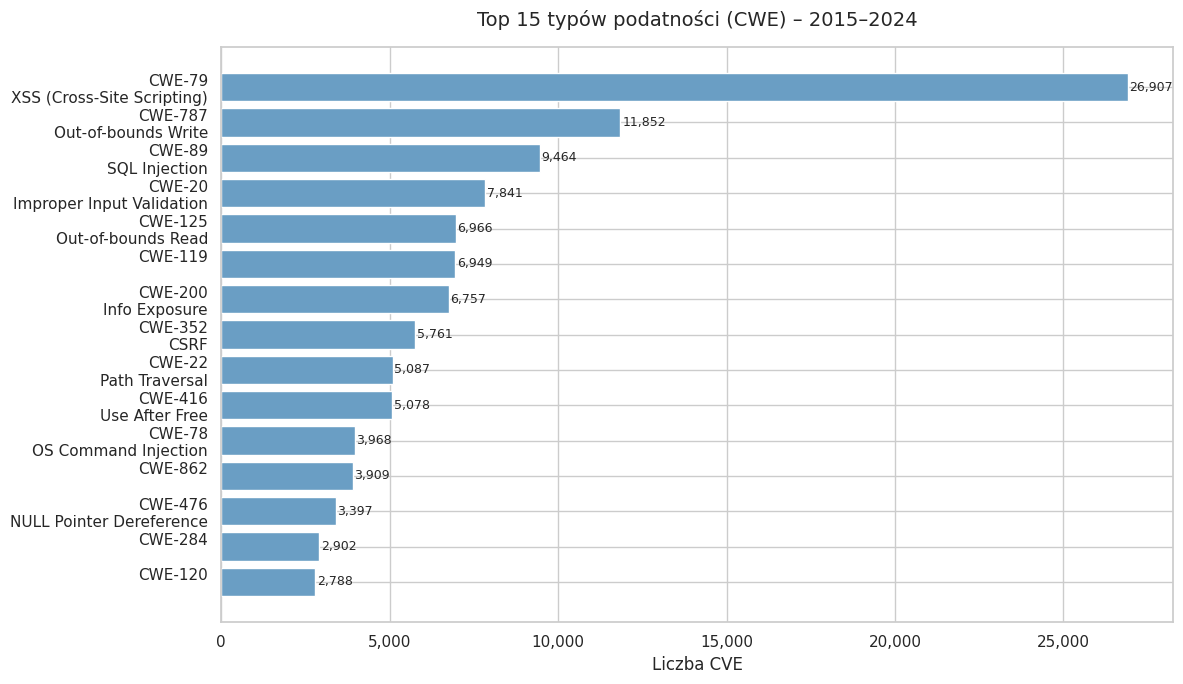

In [53]:
# Słownik najpopularniejszych CWE z nazwami
CWE_NAMES = {
    "CWE-79":  "XSS (Cross-Site Scripting)",
    "CWE-89":  "SQL Injection",
    "CWE-20":  "Improper Input Validation",
    "CWE-125": "Out-of-bounds Read",
    "CWE-787": "Out-of-bounds Write",
    "CWE-22":  "Path Traversal",
    "CWE-78":  "OS Command Injection",
    "CWE-416": "Use After Free",
    "CWE-476": "NULL Pointer Dereference",
    "CWE-190": "Integer Overflow",
    "CWE-200": "Info Exposure",
    "CWE-287": "Improper Authentication",
    "CWE-352": "CSRF",
    "CWE-400": "Uncontrolled Resource Consumption",
    "CWE-434": "Unrestricted File Upload",
    "CWE-502": "Deserialization of Untrusted Data",
    "CWE-611": "XML External Entity (XXE)",
    "CWE-798": "Hard-coded Credentials",
    "CWE-918": "SSRF",
    "CWE-94":  "Code Injection",
}

# Rozwijamy pipe-separated CWE
cwe_series = (
    df[df["cwe"] != "N/A"]["cwe"]
    .str.split("|")
    .explode()
    .str.strip()
)
cwe_counts = cwe_series.value_counts().head(15)

# Mapujemy na nazwy
cwe_labels = [
    f"{cwe}\n{CWE_NAMES.get(cwe, '')}" for cwe in cwe_counts.index
]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(cwe_labels[::-1], cwe_counts.values[::-1], color="#6a9ec4", edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)

ax.set_title("Top 15 typów podatności (CWE) – 2015–2024", fontsize=14, pad=15)
ax.set_xlabel("Liczba CVE")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/wykres_cwe_top15.png", dpi=150)
plt.show()

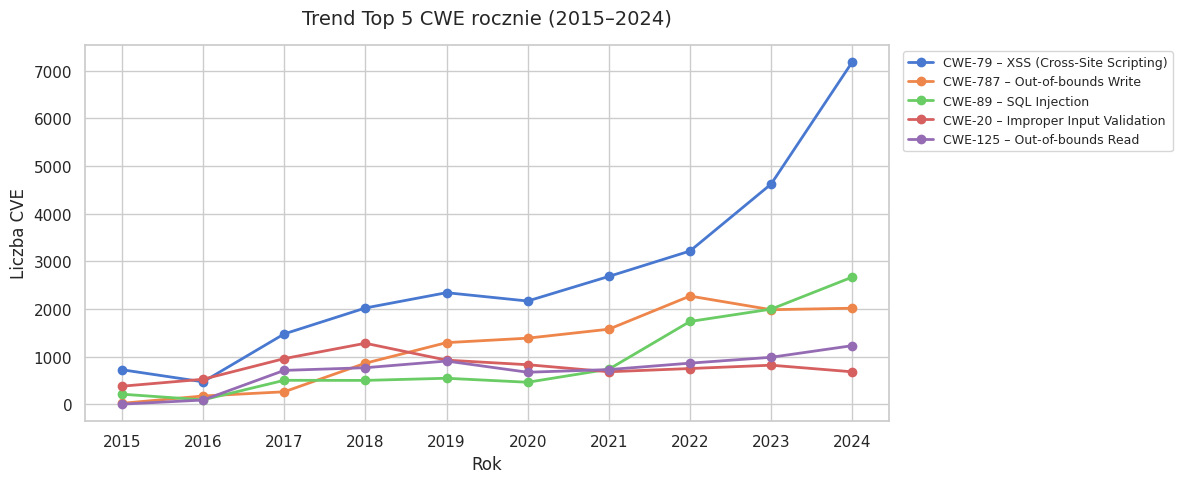

In [54]:
# --- Trend top 5 CWE rocznie ---
top5_cwe = cwe_counts.head(5).index.tolist()

# Rozwijamy CWE z zachowaniem roku
df_cwe_exp = df[["year", "cwe"]].copy()
df_cwe_exp = df_cwe_exp[df_cwe_exp["cwe"] != "N/A"]
df_cwe_exp = df_cwe_exp.assign(cwe=df_cwe_exp["cwe"].str.split("|")).explode("cwe")
df_cwe_exp["cwe"] = df_cwe_exp["cwe"].str.strip()

cwe_trend = (
    df_cwe_exp[df_cwe_exp["cwe"].isin(top5_cwe)]
    .groupby(["year", "cwe"]).size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for cwe in top5_cwe:
    if cwe in cwe_trend.columns:
        label = f"{cwe} – {CWE_NAMES.get(cwe, cwe)}"
        ax.plot(cwe_trend.index, cwe_trend[cwe], marker="o", label=label, linewidth=2)

ax.set_title("Trend Top 5 CWE rocznie (2015–2024)", fontsize=14, pad=15)
ax.set_xlabel("Rok")
ax.set_ylabel("Liczba CVE")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticks(list(range(START_YEAR, END_YEAR + 1)))
plt.tight_layout()
plt.savefig("../data/wykres_cwe_trend.png", dpi=150)
plt.show()

---
## 7. Analiza 4 – Top vendorzy i produkty <a id='7'></a>

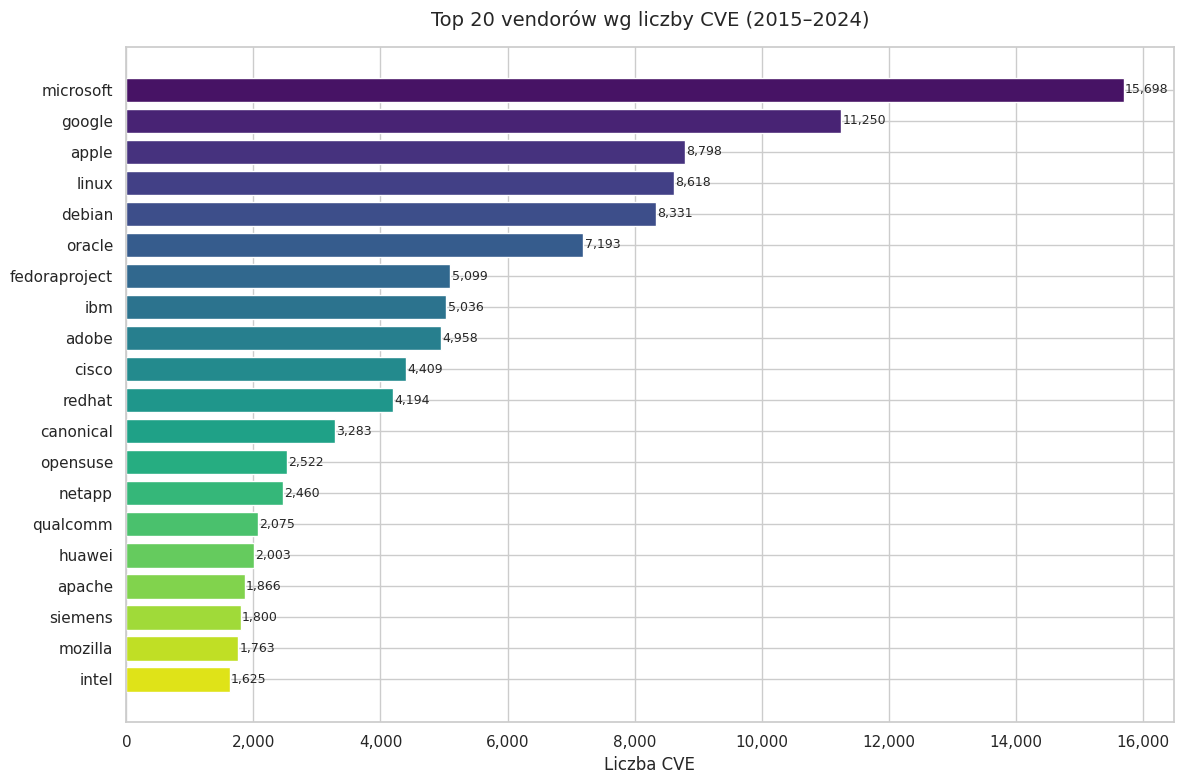

In [57]:
# Rozwijamy vendorów (pipe-separated)
vendor_series = (
    df[df["vendors"] != "N/A"]["vendors"]
    .str.split("|")
    .explode()
    .str.strip()
    .str.lower()
)

# Filtrujemy generyczne wpisy
EXCLUDE = {"n/a", "", "*", "-"}
vendor_series = vendor_series[~vendor_series.isin(EXCLUDE)]

vendor_counts = vendor_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("viridis_r", len(vendor_counts))
bars = ax.barh(vendor_counts.index[::-1], vendor_counts.values[::-1], color=palette)

for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)

ax.set_title("Top 20 vendorów wg liczby CVE (2015–2024)", fontsize=14, pad=15)
ax.set_xlabel("Liczba CVE")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/wykres_vendorzy.png", dpi=150)
plt.show()

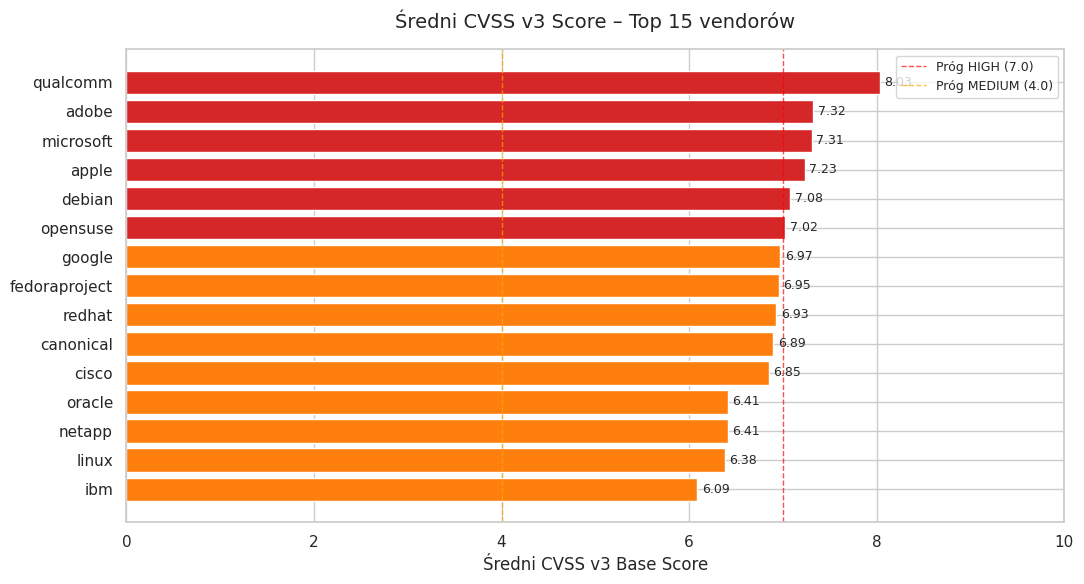

In [58]:
# --- Średni CVSS v3 score dla top 15 vendorów ---
df_vendor_exp = df[["vendors", "cvss_v3_score"]].copy()
df_vendor_exp = df_vendor_exp[df_vendor_exp["vendors"] != "N/A"]
df_vendor_exp = df_vendor_exp.assign(
    vendor=df_vendor_exp["vendors"].str.split("|")
).explode("vendor")
df_vendor_exp["vendor"] = df_vendor_exp["vendor"].str.strip().str.lower()
df_vendor_exp = df_vendor_exp[~df_vendor_exp["vendor"].isin(EXCLUDE)]

top15_vendors = vendor_counts.head(15).index.tolist()
vendor_avg_cvss = (
    df_vendor_exp[df_vendor_exp["vendor"].isin(top15_vendors)]
    .groupby("vendor")["cvss_v3_score"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 6))
colors_bar = ["#d62728" if v >= 7 else "#ff7f0e" if v >= 4 else "#2ca02c" for v in vendor_avg_cvss.values]
bars = ax.barh(vendor_avg_cvss.index[::-1], vendor_avg_cvss.values[::-1], color=colors_bar[::-1])

for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}", va="center", fontsize=9)

ax.axvline(7.0, color="red",    linestyle="--", linewidth=1, alpha=0.7, label="Próg HIGH (7.0)")
ax.axvline(4.0, color="orange", linestyle="--", linewidth=1, alpha=0.7, label="Próg MEDIUM (4.0)")
ax.set_xlim(0, 10)
ax.set_title("Średni CVSS v3 Score – Top 15 vendorów", fontsize=14, pad=15)
ax.set_xlabel("Średni CVSS v3 Base Score")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/wykres_vendor_cvss.png", dpi=150)
plt.show()

---
## 8. Wnioski końcowe <a id='8'></a>

In [59]:
# Automatyczne podsumowanie statystyk do wpisania do sprawozdania
total       = len(df)
year_max    = cve_per_year.loc[cve_per_year["count"].idxmax()]
pct_high_crit = (
    df["cvss_v3_severity"].isin(["CRITICAL", "HIGH"]).sum() / df["cvss_v3_score"].notna().sum() * 100
)
top_cwe_name  = CWE_NAMES.get(cwe_counts.index[0], cwe_counts.index[0])
top_vendor    = vendor_counts.index[0]

print("=" * 55)
print("PODSUMOWANIE PROJEKTU")
print("=" * 55)
print(f"Analizowany okres:      {START_YEAR}–{END_YEAR}")
print(f"Łączna liczba CVE:      {total:,}")
print(f"Rok z największą l. CVE: {int(year_max['year'])} ({int(year_max['count']):,} CVE)")
print(f"CVE z oceną CRITICAL/HIGH: {pct_high_crit:.1f}% sklasyfikowanych")
print(f"Najczęstszy typ (CWE):  {cwe_counts.index[0]} – {top_cwe_name}")
print(f"Vendor z największą l. CVE: {top_vendor}")
print("=" * 55)
print("\nWykresy zapisano do katalogu ../data/")

PODSUMOWANIE PROJEKTU
Analizowany okres:      2015–2024
Łączna liczba CVE:      207,573
Rok z największą l. CVE: 2024 (40,704 CVE)
CVE z oceną CRITICAL/HIGH: 52.4% sklasyfikowanych
Najczęstszy typ (CWE):  CWE-79 – XSS (Cross-Site Scripting)
Vendor z największą l. CVE: microsoft

Wykresy zapisano do katalogu ../data/
